In [1]:
from pathlib import Path
import contextlib

import pandas as pd
from val_utils import compute_stats
from val_utils import plot_compass_confusion_matrix_from_data

import matplotlib
matplotlib.rcParams.update(matplotlib.rcParamsDefault)

In [2]:
results_fp = Path("./results/ghp_extraction_june_2026.csv").resolve()
out_dir = results_fp.parent
plots_out_dir = out_dir / "plots"
plots_out_dir.mkdir(exist_ok=True)

In [3]:
results = pd.read_csv(results_fp)

In [4]:
results.Score.value_counts()

Score
Correct (DNE)                               355
Correct (Exists)                             90
Intern value wrong, LLM correct (Exists)     27
Value exists but LLM did not find            14
Intern value wrong, LLM correct (DNE)        10
Value does not exist but LLM reported it      9
Value exists but LLM got it wrong             5
Name: count, dtype: int64

In [5]:
correct_doc_compare = results[
    results["Score"] != "Bad web scrape"
].copy()

In [6]:
len(
    correct_doc_compare.groupby(
        ["State", "County", "Subdivision", "Jurisdiction Type"]
    )
)

15

In [7]:
correct_doc_compare["Jurisdiction Type"].value_counts()

Jurisdiction Type
County    238
Town      238
City       34
Name: count, dtype: int64

In [8]:
exist_cats = {
    "Correct (Exists)",
    "Intern value wrong, LLM correct (Exists)",
    "Intern value wrong, LLM wrong also",
    "Value exists but LLM did not find",
    "Value exists but LLM got it wrong",
}

correct_doc_compare["ordinance_value_exists"] = (
    correct_doc_compare["Score"].apply(
        lambda x: int(x in exist_cats)
    )
)

correct_doc_compare["ordinance_value_exists"].value_counts()

ordinance_value_exists
0    374
1    136
Name: count, dtype: int64

In [9]:
score_cats = {
    "dne_no_report": {
        "Correct (DNE)",
        "Intern value wrong, LLM correct (DNE)"
    },
    "exists_report": {
        "Correct (Exists)",
        "Intern value wrong, LLM correct (Exists)",
    },
    "dne_report": {"Value does not exist but LLM reported it"},
    "exists_bad_report": {
        "Intern value wrong, LLM wrong also",
        "Value exists but LLM got it wrong"
    },
    "exists_no_report": {"Value exists but LLM did not find"},
}

In [10]:
truth_labels_col = "ordinance_value_exists"

out = compute_stats(
    correct_doc_compare,
    score_cats,
    truth_labels_col=truth_labels_col,
)
compass_cm, compass_acc, compass_precision, compass_recall, compass_f1 = out


print("COMPASS")
print("confusion matrix:\n", compass_cm)
print(
    f"accuracy={compass_acc:.2%}, "
    f"precision={compass_precision:.2%}, "
    f"recall={compass_recall:.2%}, "
    f"F1={compass_f1:.2%}"
)

COMPASS
confusion matrix:
 [[117  19]
 [  9 365]]
accuracy=94.51%, precision=89.31%, recall=86.03%, F1=87.64%


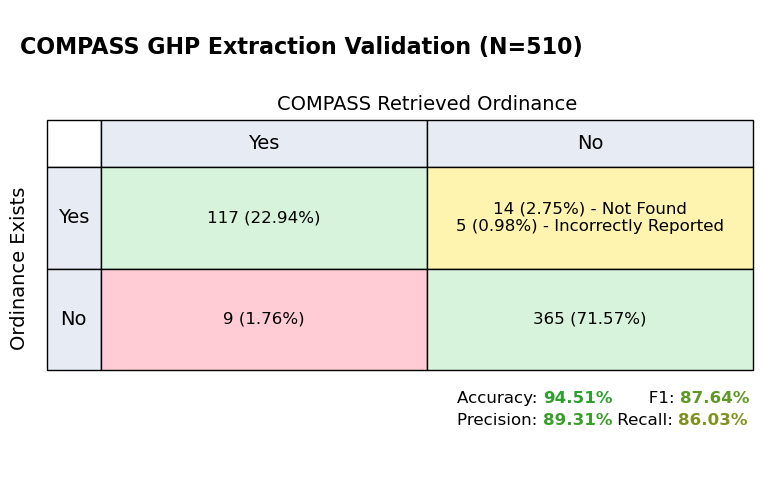

In [11]:
plot_compass_confusion_matrix_from_data(
    correct_doc_compare,
    score_cats,
    title="COMPASS GHP Extraction Validation",
    truth_labels_col=truth_labels_col,
    x_label="COMPASS Retrieved Ordinance",
    y_label="Ordinance Exists",
    out_fp=plots_out_dir / "ghp_validation_all_ordinances.png",
    color_scores=True,
)

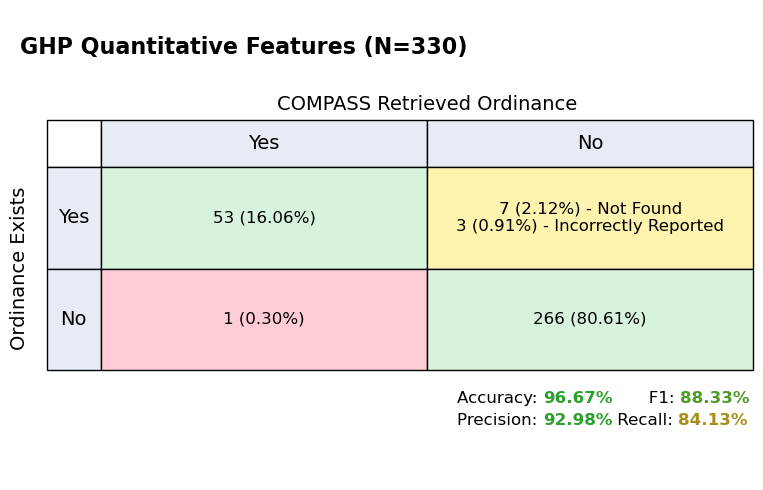

In [15]:
quant_feats = {
    "driveways",
    "property lines",
    "yards",
    "private water",
    "public water",
    "building foundation",
    "wastewater",
    "water line",
    "sewer line",
    "animal enclosures",
    "roads",
    "row",
    "above ground fuel",
    "below ground fuel",
    "subsurface drains",
    "wetlands",
    "pools",
    "hmat",
    "noise",
    "minimum well depth",
    "maximum well depth",
    "year",
}

plot_compass_confusion_matrix_from_data(
    correct_doc_compare[correct_doc_compare["Feature"].isin(quant_feats)],
    score_cats,
    title="GHP Quantitative Features",
    truth_labels_col=truth_labels_col,
    out_fp=plots_out_dir / "ghp_validation_quant.png",
    color_scores=True,
)

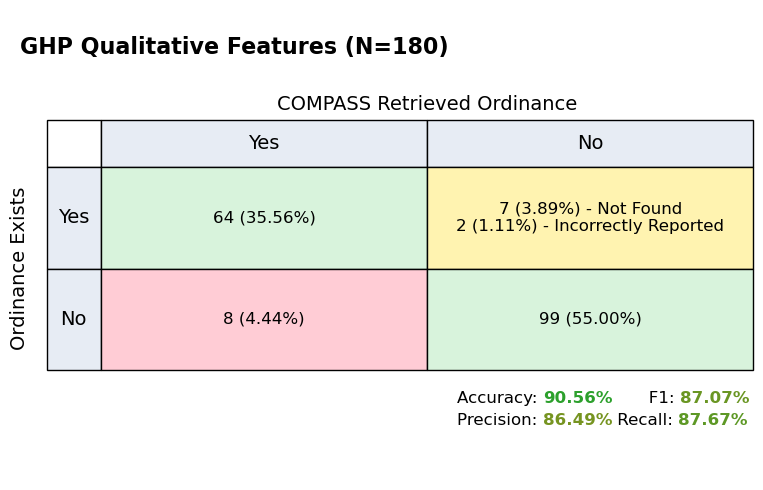

In [16]:
plot_compass_confusion_matrix_from_data(
    correct_doc_compare[~correct_doc_compare["Feature"].isin(quant_feats)],
    score_cats,
    title="GHP Qualitative Features",
    truth_labels_col=truth_labels_col,
    out_fp=plots_out_dir / "ghp_validation_qual.png",
    color_scores=True,
)

In [20]:
all_stats = []
for feature in correct_doc_compare["Feature"].unique():
    data = correct_doc_compare[correct_doc_compare["Feature"] == feature]
    __, a, p, r, f1 = compute_stats(
        data, score_cats, truth_labels_col=truth_labels_col
    )
    num_values = data["ordinance_value_exists"].sum()
    num_found = (
        data["Score"].isin(
            score_cats["exists_report"]
            | score_cats["exists_bad_report"]
            | score_cats["dne_report"]
        )
    ).sum()
    num_found_correctly = (
        data["Score"].isin(score_cats["exists_report"])
    ).sum()

    all_stats.append(
        [
            feature,
            a * 100,
            p * 100,
            r * 100,
            num_values,
            num_found,
            num_found_correctly
        ]
    )

pra_breakdown = pd.DataFrame(
    all_stats,
    columns=[
        "feature",
        "Accuracy",
        "Precision",
        "Recall",
        "# non-null Ordinances",
        "# Ordinances reported by COMPASS",
        "# Ordinances correctly reported by COMPASS"
    ]
)

pra_breakdown.to_csv(out_dir / "pra_breakdown.csv", index=False)
pra_breakdown

/home/ppinchuk/gitrepos/COMPASS/.pixi/envs/pdev/lib/python3.13/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/ppinchuk/gitrepos/COMPASS/.pixi/envs/pdev/lib/python3.13/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/ppinchuk/gitrepos/COMPASS/.pixi/envs/pdev/lib/python3.13/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/ppinchuk/gitrepos/COMPASS/.pixi/envs/pdev/lib/python3.13/site-packages/sklearn/metric

,feature,Accuracy,Precision,Recall,# non-null Ordinances,# Ordinances reported by COMPASS,# Ordinances correctly reported by COMPASS
0,driveways,100.000000,0.000000,0.000000,0,0,0
1,property lines,100.000000,100.000000,100.000000,7,7,7
2,yards,100.000000,100.000000,100.000000,1,1,1
3,private water,100.000000,100.000000,100.000000,3,3,3
4,public water,100.000000,100.000000,100.000000,5,5,5
5,building foundation,100.000000,100.000000,100.000000,1,1,1
6,wastewater,86.666667,75.000000,75.000000,8,8,6
7,water line,100.000000,100.000000,100.000000,1,1,1
8,sewer line,93.333333,100.000000,80.000000,5,4,4
9,animal enclosures,93.333333,100.000000,66.666667,3,2,2


/home/ppinchuk/gitrepos/COMPASS/.pixi/envs/pdev/lib/python3.13/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


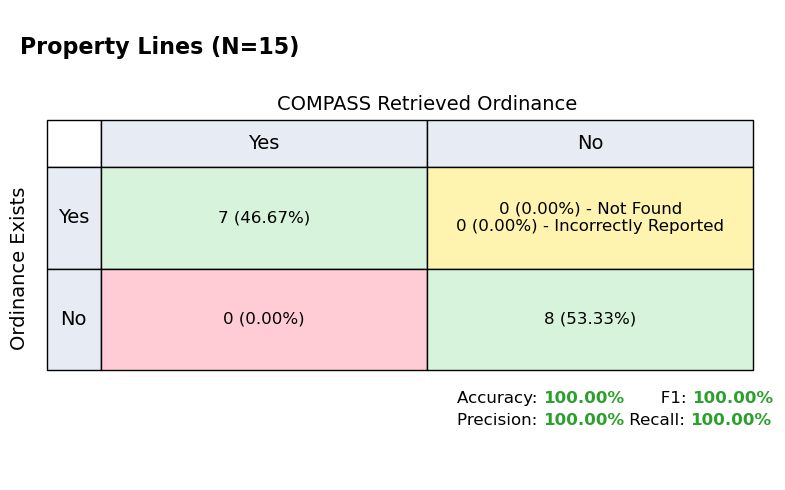

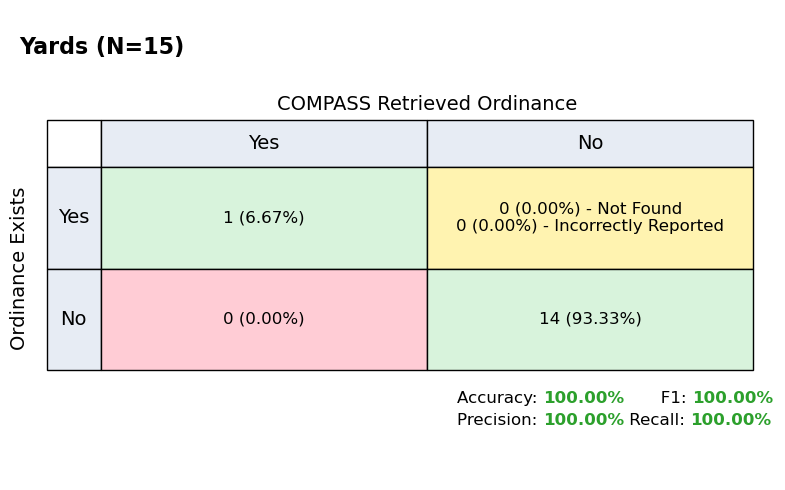

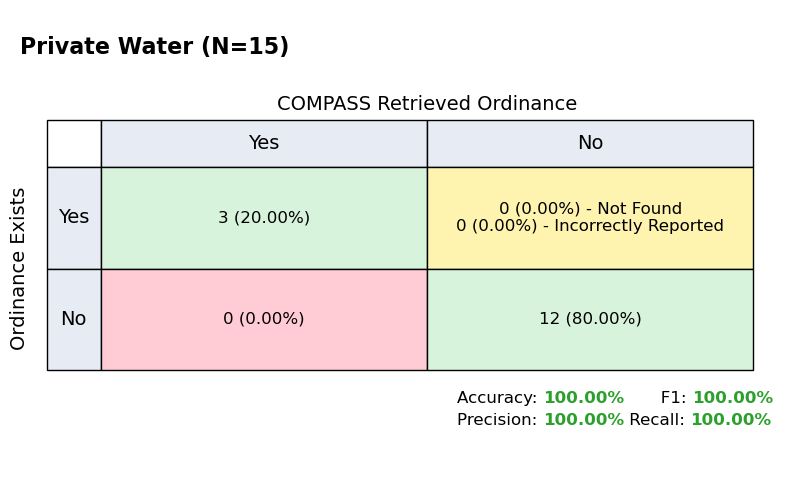

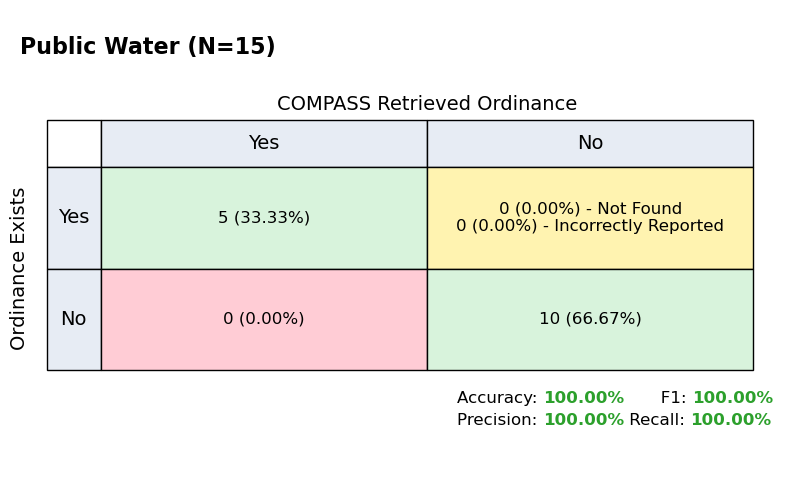

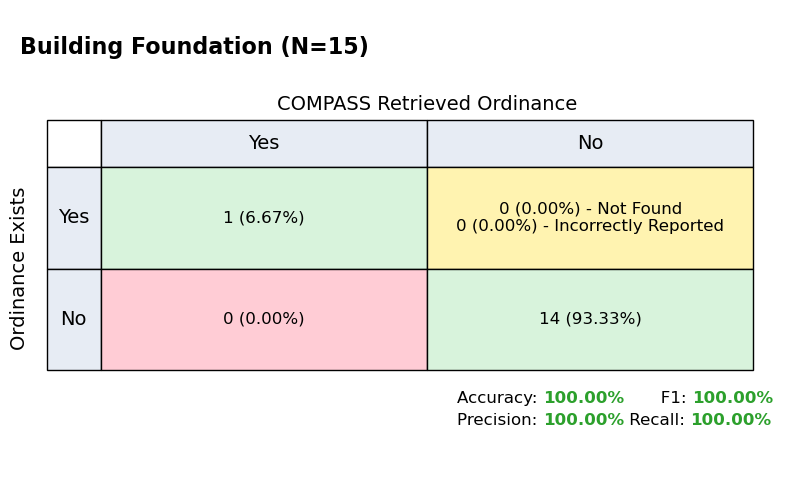

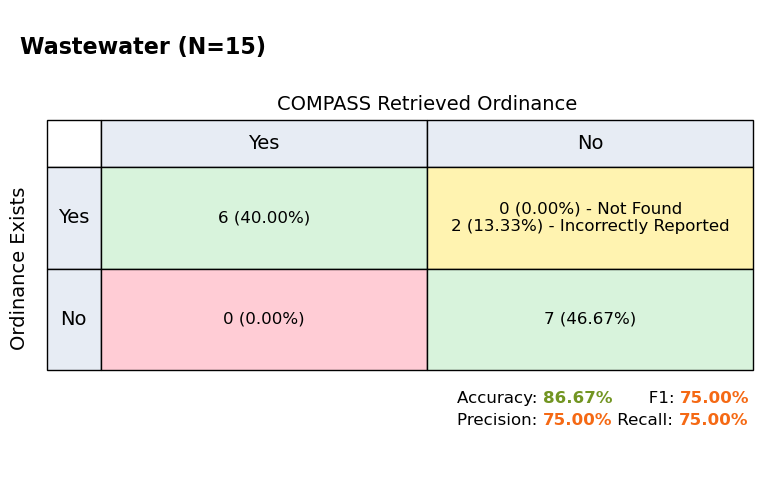

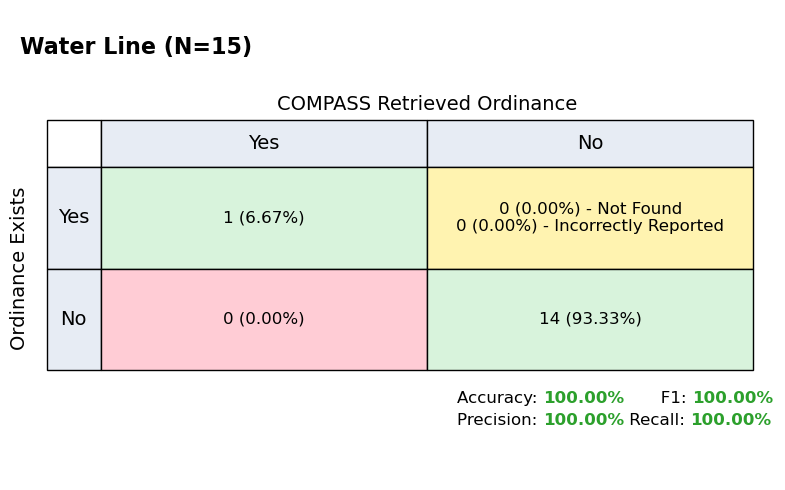

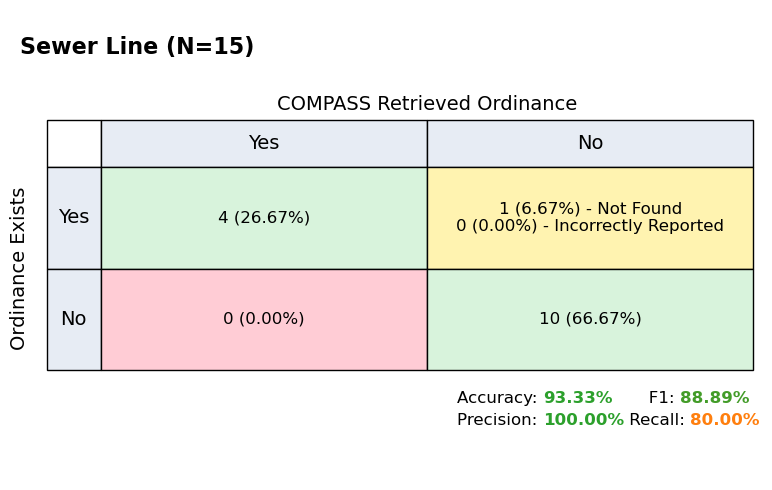

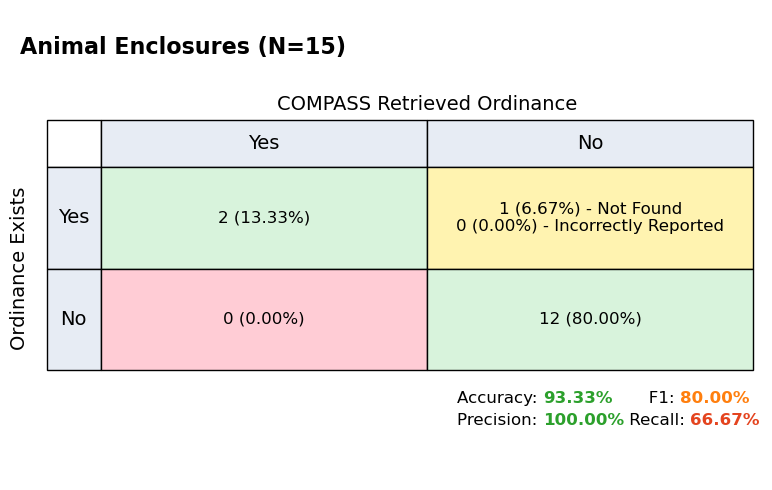

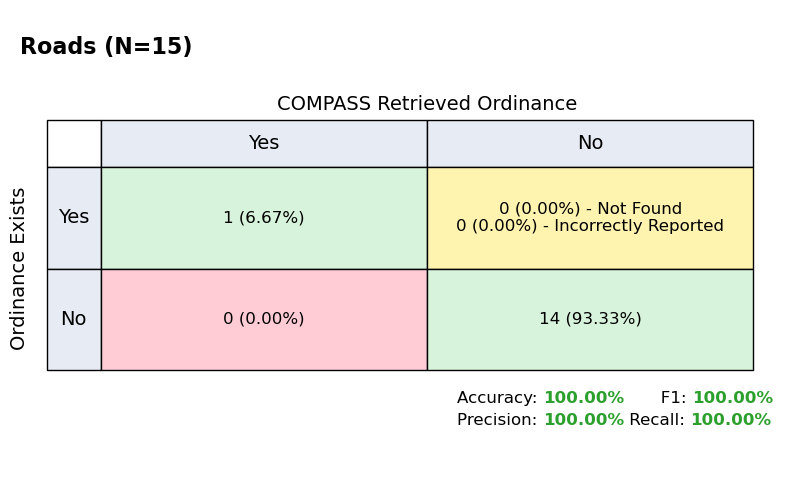

/home/ppinchuk/gitrepos/COMPASS/.pixi/envs/pdev/lib/python3.13/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


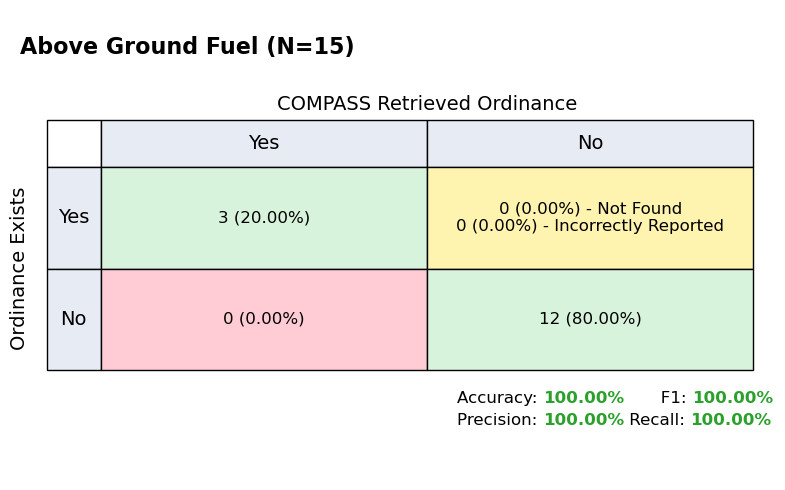

/home/ppinchuk/gitrepos/COMPASS/.pixi/envs/pdev/lib/python3.13/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/ppinchuk/gitrepos/COMPASS/.pixi/envs/pdev/lib/python3.13/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


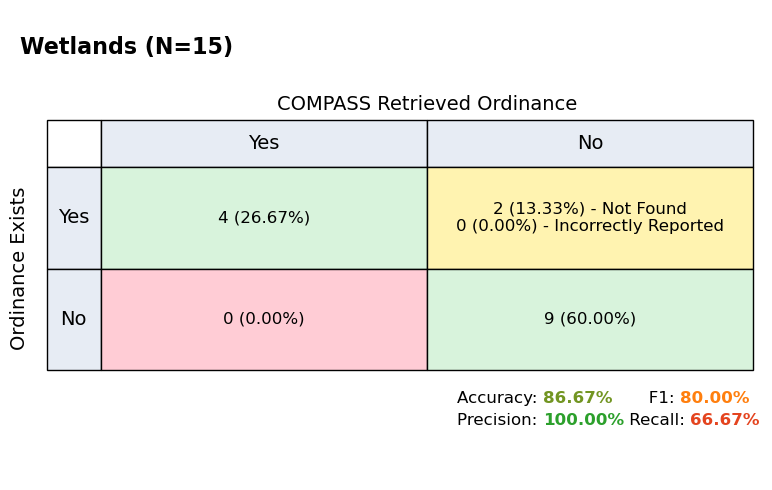

/home/ppinchuk/gitrepos/COMPASS/.pixi/envs/pdev/lib/python3.13/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


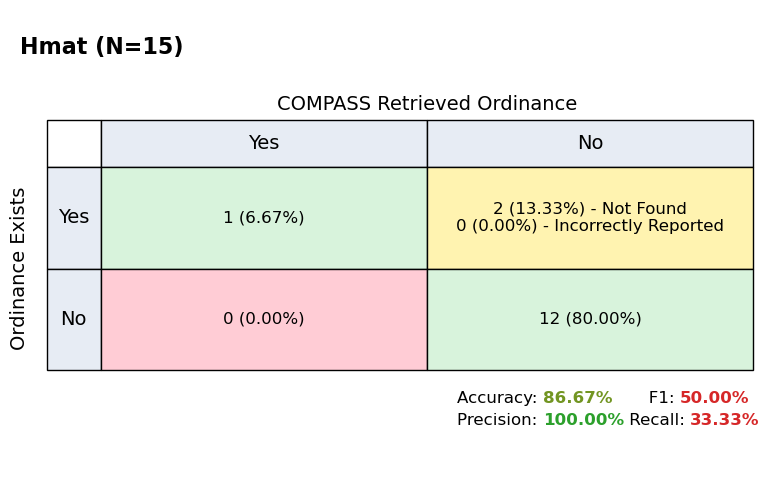

/home/ppinchuk/gitrepos/COMPASS/.pixi/envs/pdev/lib/python3.13/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


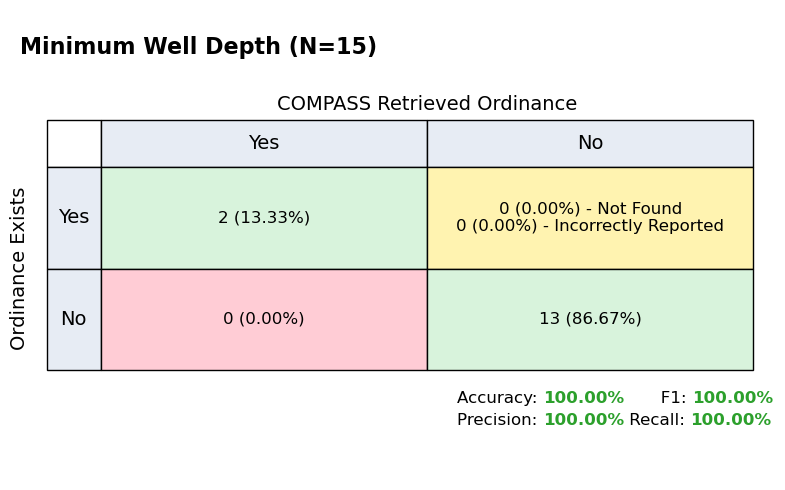

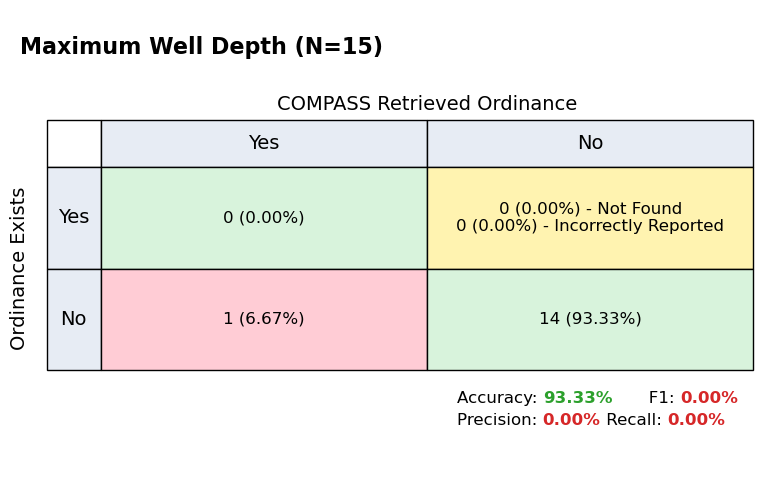

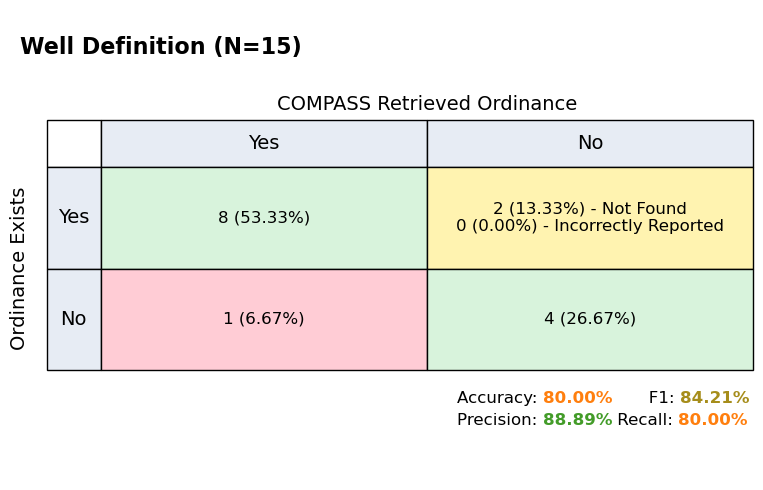

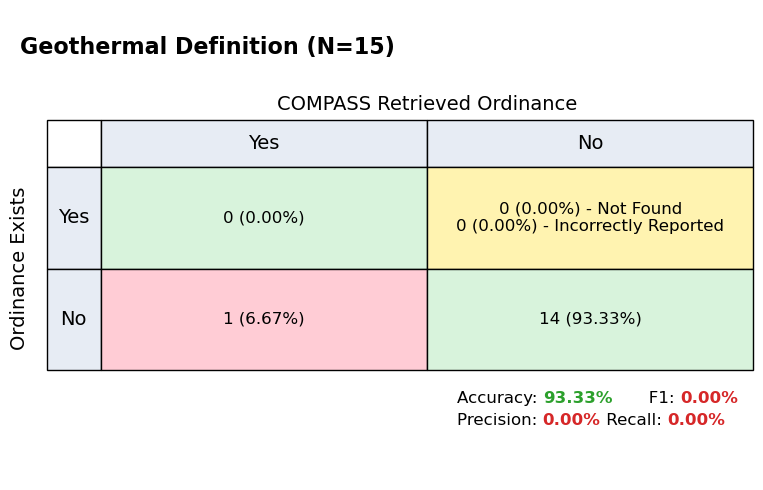

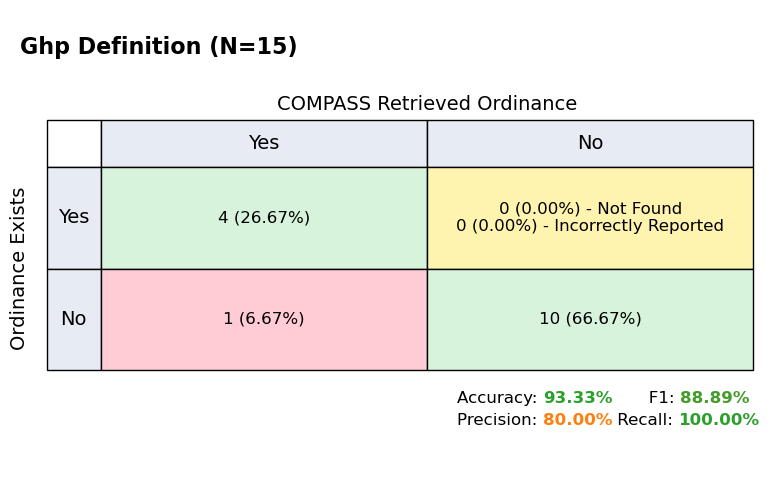

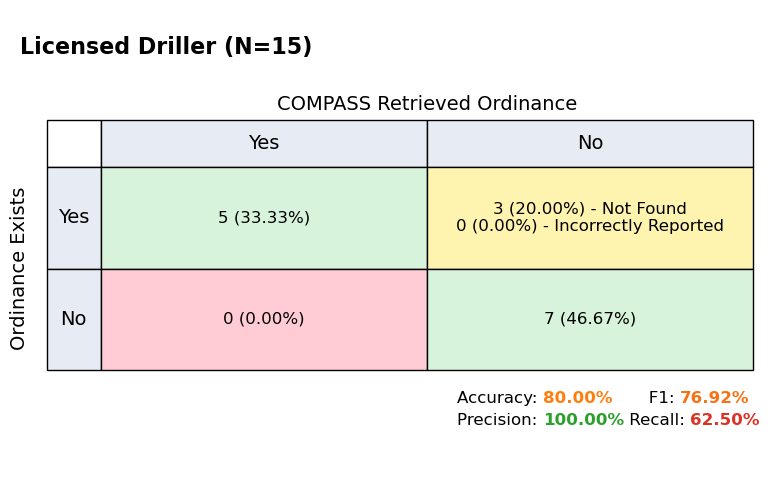

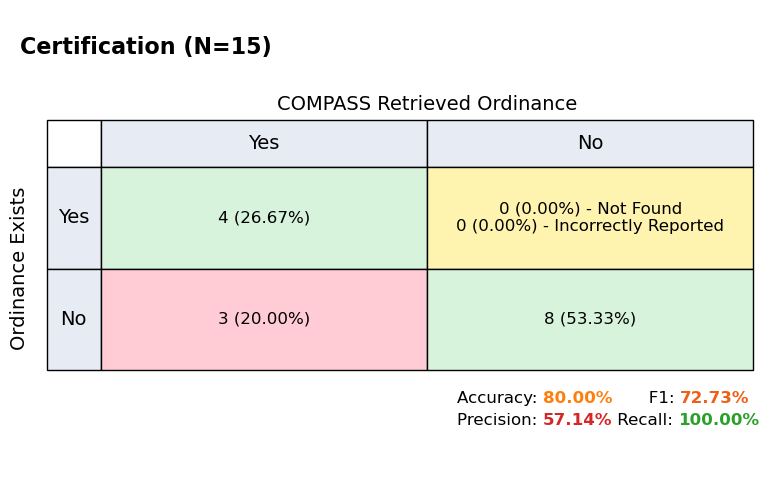

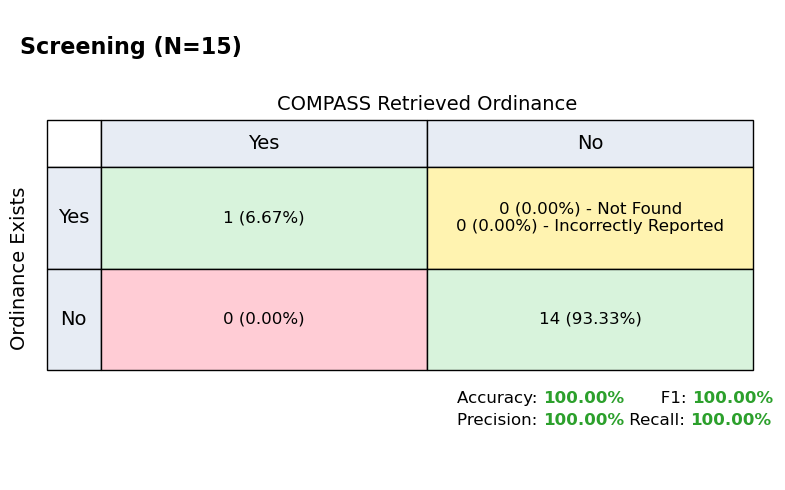

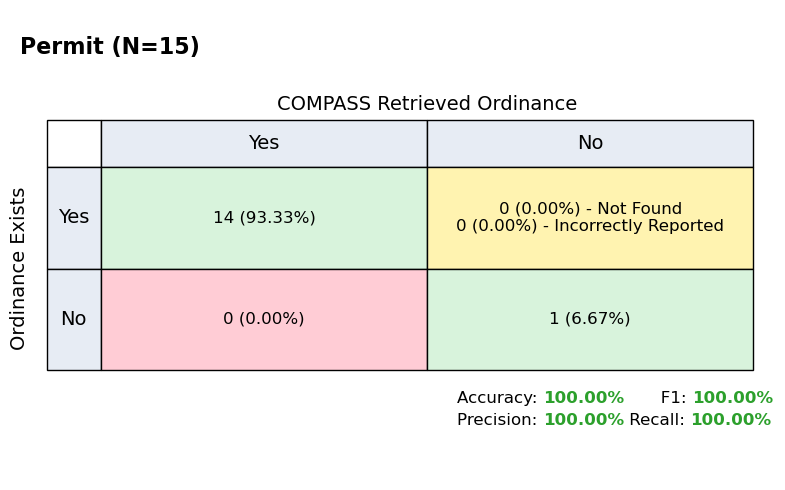

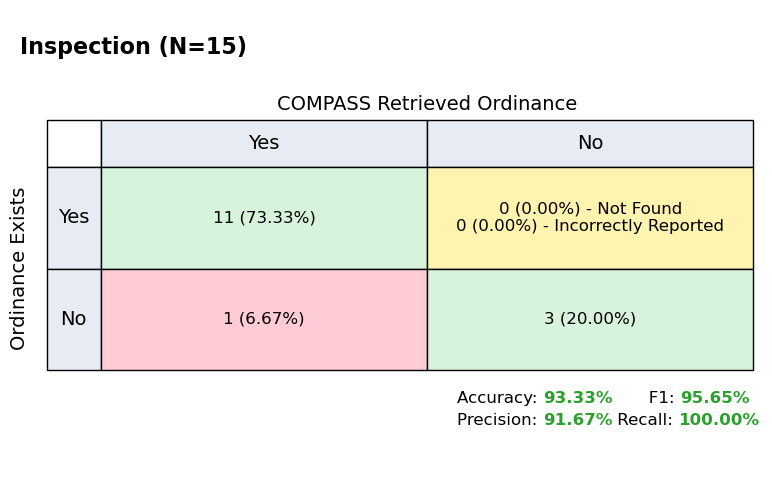

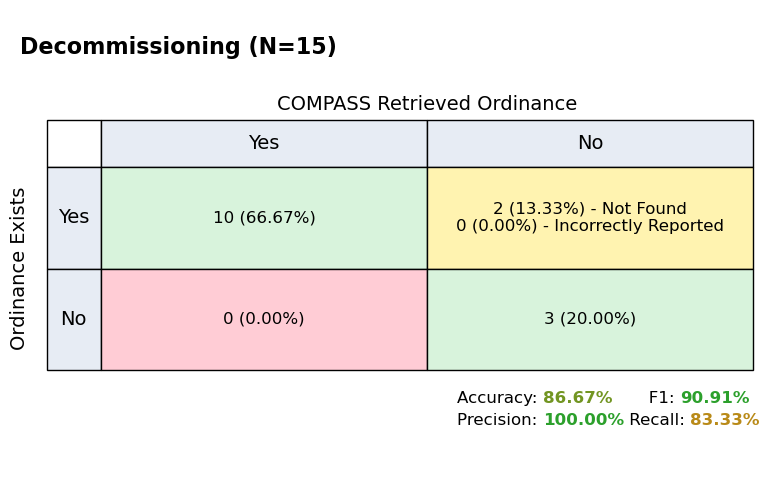

/home/ppinchuk/gitrepos/COMPASS/.pixi/envs/pdev/lib/python3.13/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


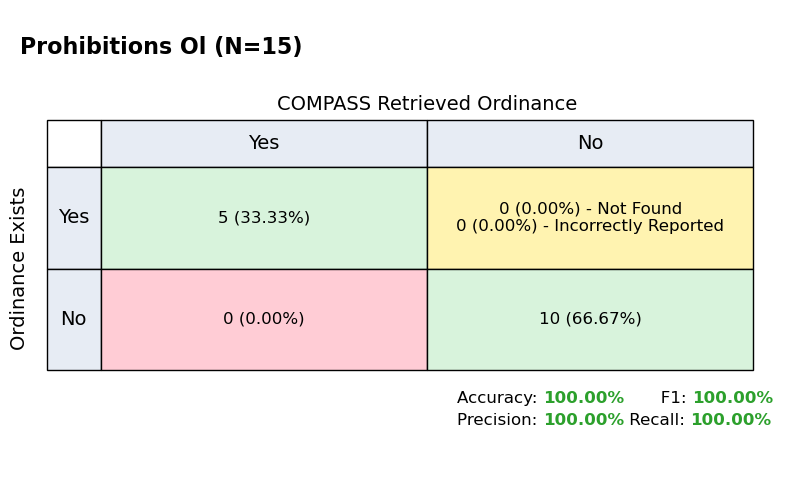

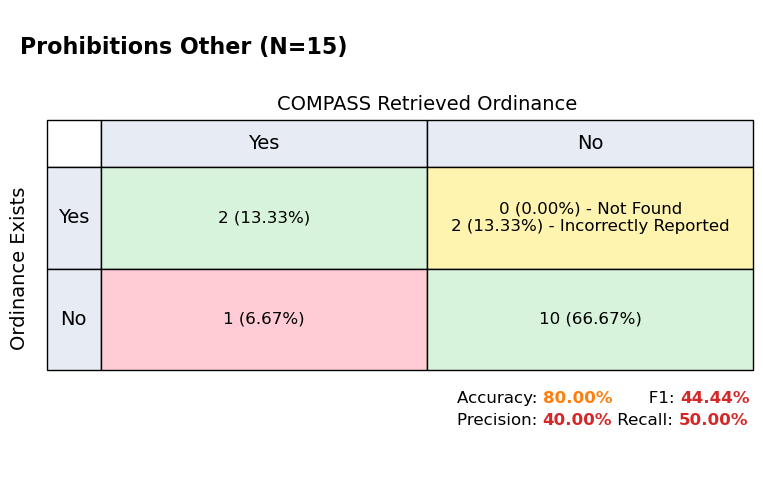

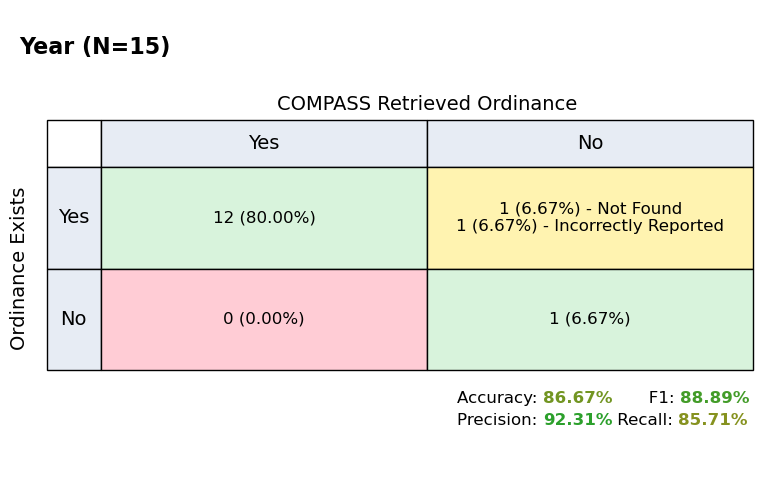

In [22]:
for feature in correct_doc_compare["Feature"].unique():
    data = correct_doc_compare[correct_doc_compare["Feature"] == feature]
    plot_out_fn = f"ghp_validation_{feature}.png"
    plot_out_fn = (
        plot_out_fn.replace(" ", "_").replace("(", "").replace(")", "")
    )
    with contextlib.suppress(IndexError):
        plot_compass_confusion_matrix_from_data(
            data,
            score_cats,
            title=feature.title(),
            truth_labels_col=truth_labels_col,
            out_fp=plots_out_dir / plot_out_fn,
            color_scores=True,
        )